
# Introducción práctica a Keras y TensorFlow (Cap. 3)

Este notebook unifica el contenido teórico del libro de François Chollet (*Deep Learning with Python*, 2ª ed., Capítulo 3) con ejemplos prácticos de código.  
El objetivo es comprender el **flujo de trabajo en Keras** y el rol de TensorFlow como backend.


## 1. TensorFlow y Keras

- **TensorFlow**: librería de *computación con tensores* y autodiferenciación.  
- **Keras**: API de alto nivel sobre TensorFlow, facilita la construcción de redes.  
- Flujo de trabajo típico: **definir → compilar → entrenar → evaluar → predecir**.

In [1]:

import tensorflow as tf
from tensorflow import keras

print("Versión de TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))


Versión de TensorFlow: 2.11.0
GPU disponible: []


> Siempre revisa tu versión de TensorFlow/Keras para reproducibilidad y compatibilidad.


## 2. Tensores en TensorFlow

Un **tensor** es un arreglo multidimensional. TensorFlow maneja tensores como base del cálculo numérico.

- `tf.constant`: valores inmutables.  
- `tf.Variable`: parámetros que pueden cambiar (como pesos).  

> Ojo: Para realizar cualquier acción en TensorFlow, necesitaremos tensores. Estos deben crearse con un valor inicial. Por ejemplo, se pueden crear tensores de solo unos o de solo ceros, o tensores con valores extraídos de una distribución aleatoria

In [2]:

# Ejemplo de tensores básicos
x = tf.constant([[1,2],[3,4]], dtype=tf.float32)
w = tf.Variable(tf.random.normal((2,2)))

print("Tensor constante:", x.numpy())
print("Variable con pesos aleatorios:", w.numpy())


Tensor constante: [[1. 2.]
 [3. 4.]]
Variable con pesos aleatorios: [[ 1.0051877 -1.4560344]
 [-0.550649  -1.0690196]]


**All-ones or all-zeros tensors**

In [ ]:
x = tf.ones(shape=(2, 1))
print(x)

tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)


In [2]:
x = tf.zeros(shape=(2, 1))
print(x)

tf.Tensor(
[[0.]
 [0.]], shape=(2, 1), dtype=float32)


**Random tensors**

In [ ]:
# Tensor of random values drawn from a normal distribution
# with mean 0 and standard deviation 1. Equivalent to
# np.random.normal(size=(3, 1), loc=0., scale=1.).
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[-2.156666  ]
 [ 0.24201183]
 [-0.7739118 ]], shape=(3, 1), dtype=float32)


In [ ]:
# Tensor of random values drawn from a uniform distribution between 0
# and 1. Equivalent to np.random.uniform(size=(3, 1), low=0., high=1.).
x = tf.random.uniform(shape=(3, 1), minval=0, maxval=1)
print(x)

tf.Tensor(
[[0.19109523]
 [0.48514116]
 [0.86983716]], shape=(3, 1), dtype=float32)


**NumPy arrays are assignable**

Una diferencia significativa entre los arrays de NumPy y los tensores de TensorFlow es que los tensores de TensorFlow no son asignables: son constantes. Por ejemplo, en NumPy, puedes hacer lo siguiente.

In [11]:
import numpy as np
x = np.ones(shape=(2, 2))
x[0, 0] = 0.
x

array([[0., 1.],
       [1., 1.]])

Si intentamos algo similar en TF obtendremos un error. 

In [7]:
x = tf.ones(shape=(2, 2))
x[0, 0] = 0.

TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

**Creating a TensorFlow variable**

Para entrenar un modelo, necesitamos actualizar su estado, que es un conjunto de tensores. Si los tensores no son asignables, ¿cómo lo hacemos? Aquí es donde entran en juego las variables. `tf.Variable` es la clase diseñada para gestionar las modificaciones en los tensores. 

In [12]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[-0.03752087],
       [ 1.0301583 ],
       [ 0.16576491]], dtype=float32)>


**Assigning a value to a TensorFlow variable**

In [13]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

**Assigning a value to a subset of a TensorFlow variable**

In [14]:
v[0, 0].assign(3)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

De manera similar, `assign_add()` y `assign_sub()` son equivalentes eficientes de += y -=, como se muestra a continuación.

**Using `assign_add`**

In [15]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

#### Tensor operations: Doing math in TensorFlow

**A few basic math operations**

In [16]:
a = tf.ones((2, 2))
b = tf.square(a) # Eleva al cuadrado
c = tf.sqrt(a) # Saca la Raiz
d = b + c # Suma
e = tf.matmul(a, b) # Producto interior
e *= d # Producto elemento a elemento

#### A second look at the GradientTape API

TensorFlow se parece mucho a NumPy. Pero hay algo que NumPy no puede hacer: recuperar el gradiente de ninguna expresión diferenciable con respecto a ninguna de sus entradas. 
Simplemente con `GradientTape`, aplicamos algún cálculo a uno o varios tensores de entrada y recuperamos el gradiente del resultado con respecto a las entradas.

**Using the `GradientTape`**

In [20]:
input_var = tf.Variable(initial_value=3.)
with tf.GradientTape() as tape:
   result = tf.square(input_var)
gradient = tape.gradient(result, input_var)
gradient

<tf.Tensor: shape=(), dtype=float32, numpy=6.0>

**Using `GradientTape` with constant tensor inputs**

De hecho, es posible que los inputs sean cualquier tensor arbitrario. Sin embargo, por defecto, solo se rastrean las variables entrenables. Con un tensor constante, habría que marcarlo manualmente como rastreado mediante la función `tape.watch()`.

In [22]:
input_const = tf.constant(3.)
with tf.GradientTape() as tape:
   tape.watch(input_const)
   result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

gradient

<tf.Tensor: shape=(), dtype=float32, numpy=6.0>

¿Por qué es esto necesario? Porque sería demasiado costoso almacenar la información necesaria para calcular el gradiente de cualquier cosa con respecto a cualquier otra. Para evitar el desperdicio de recursos, necesitamos saber qué observar. 

Noten que las variables entrenables se observan por defecto porque calcular el gradiente de una pérdida con respecto a una lista de variables entrenables es el uso más común de la cinta de gradiente.

**Using nested gradient tapes to compute second-order gradients**

 `GradientTape` es una herramienta potente, capaz incluso de calcular gradientes de segundo orden, es decir, el gradiente de un gradiente. Por ejemplo, el gradiente de la posición de un objeto con respecto al tiempo es su velocidad, y el gradiente de segundo orden es su aceleración.

Ejemplo: Supongamos que medimos la posición de una manzana que cae a lo largo de un eje vertical a lo largo del tiempo y encuentras que verifica la siguiente regla:

$$posición(tiempo) = 4.9 * tiempo^2$$

¿cuál es su aceleración? Usemos dos cintas de gradiente anidadas para averiguarlo.


In [ ]:
time = tf.Variable(0.)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position =  4.9 * time ** 2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)

acceleration

<tf.Tensor: shape=(), dtype=float32, numpy=9.8>

#### An end-to-end example: A linear classifier in pure TensorFlow

Propongamos datos sintéticos linealmente separables con los que trabajar:
dos clases de puntos en un plano 2D. Generaremos cada clase de puntos dibujando sus coordenadas a partir de una distribución aleatoria con una matriz de covarianza y una media específicas. Intuitivamente, la matriz de covarianza describe la forma de la nube de puntos, y la media describe su posición en el plano

Reutilizaremos la misma matriz de covarianza para ambas nubes de puntos, pero usaremos dos valores medios diferentes: las nubes de puntos tendrán la misma forma, pero diferentes posiciones.

**Generating two classes of random points in a 2D plane**

In [28]:
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)

positive_samples

array([[ 3.76044083, -1.11253295],
       [ 3.09388592, -1.4809368 ],
       [ 2.79609121,  0.58943969],
       ...,
       [ 1.39836437, -2.65777269],
       [ 3.71564174, -0.49331013],
       [ 5.33873812,  0.66137573]])

**Stacking the two classes into an array with shape (2000, 2)**

In [24]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

**Generating the corresponding targets (0 and 1)**

In [25]:
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

**Plotting the two point classes**

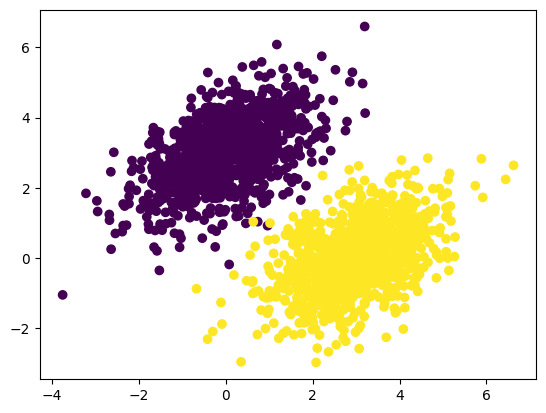

In [26]:
import matplotlib.pyplot as plt
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

**Creating the linear classifier variables**

Creamos un clasificador lineal que pueda aprender a separar estos dos conjuntos. Un clasificador lineal es una transformación afín (predicción = W • entrada + b) entrenada para minimizar el cuadrado de la diferencia entre las predicciones y los objetivos.

In [ ]:
# The inputs will be 2D points.
input_dim = 2
# The output predictions will be a single score per
# sample (close to 0 if the sample is predicted to
# be in class 0, and close to 1 if the sample is
# predicted to be in class 1).
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))

b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,))) # Escalar

**The forward pass function**

In [30]:
def model(inputs):
    return tf.matmul(inputs, W) + b

**The mean squared error loss function**

In [31]:
def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

**The training step function**

Recibe algunos datos de entrenamiento y actualiza los pesos W y b para minimizar la pérdida de datos.

La tasa de aprendizaje puede considerarse alta pero esto es porque no hay una subdivisión de batch, es decir computamos todos los gradientes. 

In [32]:
learning_rate = 0.1

def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(targets, predictions)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

**The batch training loop**

In [33]:
for step in range(40):
    loss = training_step(inputs, targets)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 4.7981
Loss at step 1: 0.5694
Loss at step 2: 0.1949
Loss at step 3: 0.1460
Loss at step 4: 0.1319
Loss at step 5: 0.1223
Loss at step 6: 0.1138
Loss at step 7: 0.1061
Loss at step 8: 0.0990
Loss at step 9: 0.0926
Loss at step 10: 0.0868
Loss at step 11: 0.0814
Loss at step 12: 0.0765
Loss at step 13: 0.0721
Loss at step 14: 0.0680
Loss at step 15: 0.0643
Loss at step 16: 0.0609
Loss at step 17: 0.0578
Loss at step 18: 0.0550
Loss at step 19: 0.0524
Loss at step 20: 0.0501
Loss at step 21: 0.0479
Loss at step 22: 0.0459
Loss at step 23: 0.0442
Loss at step 24: 0.0425
Loss at step 25: 0.0410
Loss at step 26: 0.0397
Loss at step 27: 0.0384
Loss at step 28: 0.0373
Loss at step 29: 0.0363
Loss at step 30: 0.0353
Loss at step 31: 0.0345
Loss at step 32: 0.0337
Loss at step 33: 0.0330
Loss at step 34: 0.0323
Loss at step 35: 0.0317
Loss at step 36: 0.0312
Loss at step 37: 0.0307
Loss at step 38: 0.0302
Loss at step 39: 0.0298


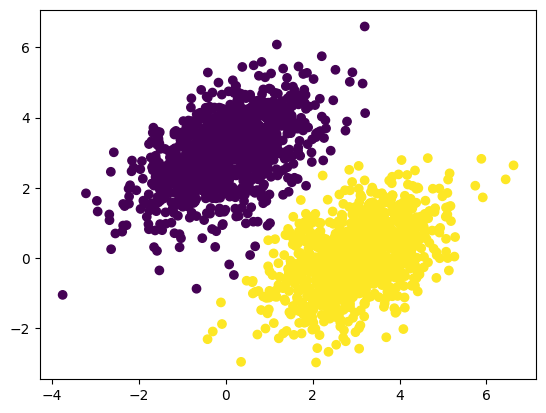

In [34]:
predictions = model(inputs)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

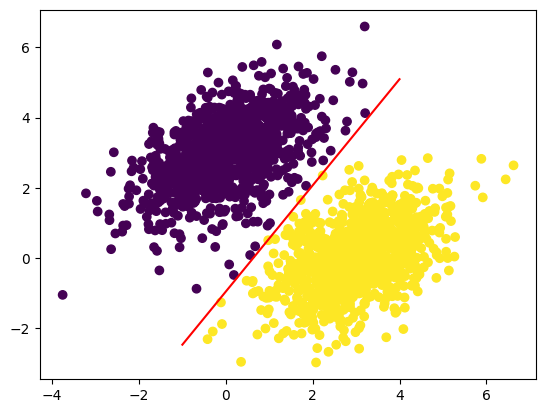

In [ ]:
# Misma regla de decisión de < .5
x = np.linspace(-1, 4, 100)
y = - W[0] /  W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

Esto es realmente de lo que se trata un clasificador lineal: encontrar los parámetros de una línea (o, en espacios de dimensiones superiores, un hiperplano) que separa claramente dos clases de datos.

## Anatomy of a neural network: Understanding core Keras APIs

### Layers: The building blocks of deep learning

Una capa es un módulo de procesamiento de datos que toma como entrada uno o más tensores y genera uno o más tensores. Algunas capas no tienen estado, pero con mayor frecuencia tienen un estado: los pesos de la capa, i.e, uno o varios tensores quepasaron por el aprendizaje mediante descenso de gradiente (estocástico), que juntos contienen "the network’s knowledge".

Diferentes tipos de capas son apropiados para diferentes formatos de tensor y diferentes tipos de procesamiento de datos.
* Los datos vectoriales simples, almacenados en tensores de forma de rango 2 (muestras, características), suelen procesarse mediante capas densamente conectadas, también llamadas fully connected o dense layers (la clase Dense en Keras). 
  
* Los datos de secuencia, almacenados en tensores de forma de rango 3 (muestras, pasos de tiempo, características), suelen procesarse mediante capas recurrentes, como LSTM o capas de convolución 1D (Conv1D).
  
* Los datos de imagen, almacenados en tensores de rango 4, suelen procesarse mediante capas de convolución 2D (Conv2D). 
 
Se puede pensar en las capas como las piezas de LEGO del aprendizaje profundo, una metáfora que Keras explicita. La construcción de modelos de aprendizaje profundo en Keras se realiza mediante la unión de capas compatibles para formar canales útiles de transformación de datos.

#### The base Layer class in Keras

Todo en Keras es una capa o algo que interactúa estrechamente con una capa.

A Layer es un objeto que encapsula un estado (pesos) y un cálculo (un paso hacia adelante). Los pesos se definen normalmente en una función `build()` (aunque también podrían crearse en el constructor, `__init__()`), y el cálculo se define en el método `call()`.

**A `Dense` layer implemented as a `Layer` subclass**

In [36]:
from tensorflow import keras

class SimpleDense(keras.layers.Layer):

    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation


# add_weight() is a shortcutmethod for creating weights.It is also possible to create
# standalone variables and assign them as layer attributes, like self.W =
# tf.Variable(tf.random.uniform(w_shape)).
    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.W = self.add_weight(shape=(input_dim, self.units),
                                 initializer="random_normal")
        self.b = self.add_weight(shape=(self.units,),
                                 initializer="zeros")

#We define theforward passcomputationin the call()method.
    def call(self, inputs):
        y = tf.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

Una vez hecho se utiliza como simples funciones. 

In [37]:
my_dense = SimpleDense(units=32, activation=tf.nn.relu)
input_tensor = tf.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


#### Automatic shape inference: Building layers on the fly

Al igual que con los bloques LEGO, solo se pueden unir capas compatibles.
El concepto de compatibilidad de capas se refiere específicamente a que cada capa solo aceptará tensores de entrada con una forma determinada y devolverá tensores de salida con una forma específica.

In [38]:
from tensorflow.keras import layers
layer = layers.Dense(32, activation="relu")

Esta capa devolverá un tensor cuya primera dimensión se ha transformado a 32. Solo se puede conectar a una capa posterior que espere vectores de 32 dimensiones como entrada.

Al usar Keras, no es necesario preocuparse por la compatibilidad de tamaño la mayor parte del tiempo, ya que las capas que se añaden a los modelos se construyen dinámicamente para adaptarse a la forma de la capa entrante. Por ejemplo, supongamos que se escribe lo siguiente:

In [39]:
from tensorflow.keras import models
from tensorflow.keras import layers
model = models.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32)
])

Las capas no recibieron ninguna información sobre la forma de sus entradas; en cambio, dedujeron automáticamente que la forma de su entrada era la forma de las primeras entradas que vieron.

Lo que nos ahorra es lo siguiente. 

```
model_2 = NaiveSequential([
NaiveDense(input_size=784, output_size=32, activation="relu"),
NaiveDense(input_size=32, output_size=64, activation="relu"),
NaiveDense(input_size=64, output_size=32, activation="relu"),
NaiveDense(input_size=32, output_size=10, activation="softmax")
])
```

Si lo evitamos con Keras el ejemplo inicial se vuelve tan sencillo como:

In [40]:
model = keras.Sequential([
    SimpleDense(32, activation="relu"),
    SimpleDense(64, activation="relu"),
    SimpleDense(32, activation="relu"),
    SimpleDense(10, activation="softmax")
])

### From layers to models

Un modelo de deep learning puede entenderse como un grafo de capas.
En Keras, esto corresponde a la clase `Model`. Hasta ahora, lo más común es usar Sequential (una subclase de `Model`), que representa una simple pila de capas con una entrada y una salida.

Sin embargo, existen muchas más topologías de redes, como:

* Redes con dos ramas (two-branch).

* Redes con múltiples cabezas (multihead).

* Conexiones residuales.

La topología puede ser muy compleja; por ejemplo, la de un Transformer, diseñado para procesar texto.

En Keras hay dos formas principales de construir estas arquitecturas:

1 *Subclasificar* directamente `Model`.

2 Usar la *API Funcional*, que permite hacer más con menos código.

La topología del modelo define el espacio de hipótesis: es decir, el conjunto de representaciones posibles que el modelo puede aprender para mapear entradas a salidas. Elegir una arquitectura equivale a imponer suposiciones sobre los datos.

Por ejemplo: si se usa una sola capa Dense sin activación para un problema binario, se está asumiendo que las clases son linealmente separables.

En conclusión, la elección de la arquitectura de red es crucial. Contiene el conocimiento previo y las restricciones que guiarán lo que el modelo puede aprender. Escogerla bien es más un arte que una ciencia: existen buenas prácticas, pero la experiencia es lo que realmente forma a un arquitecto de redes neuronales.

### The "compile" step: Configuring the learning process

Una vez definida la arquitectura del modelo, todavía es necesario elegir tres elementos clave:

1. Función de pérdida (loss function u objective function):

   * Es la cantidad que se minimizará durante el entrenamiento.

   * Representa la medida de éxito para la tarea en cuestión.

2. Optimizador:

   * Determina cómo se actualizan los pesos de la red a partir de la pérdida.

   * Implementa alguna variante del descenso de gradiente estocástico (SGD), como Adam, RMSprop, etc.

3. Métricas:

   * Son las medidas de desempeño que se monitorean durante entrenamiento y validación (por ejemplo, exactitud en clasificación).

   * A diferencia de la función de pérdida, no se optimizan directamente y por ello no necesitan ser diferenciables.

Con estos tres elementos definidos, se puede entrenar el modelo usando los métodos integrados de Keras:

   * compile() → configura el proceso de entrenamiento, recibiendo como argumentos optimizer, loss y metrics.

   * fit() → ejecuta el entrenamiento del modelo con los datos de entrada y salida.

Como alternativa, también es posible escribir bucles de entrenamiento personalizados, aunque requieren más trabajo.

In [41]:
model = keras.Sequential([keras.layers.Dense(1)]) # Clasificador Lineal
model.compile(optimizer="rmsprop", 
              loss="mean_squared_error",
              metrics=["accuracy"])

A compile(), le pasamos el optimizador, la pérdida y las métricas como strings (como "rmsprop"). Estas str son, en realidad, accesos directos que se convierten en objetos de Python. Por ejemplo, "rmsprop" se convierte en `keras.optimizers.RMSprop()`. Es importante destacar que también es posible especificar estos argumentos como instancias de objeto, como se muestra a continuación:

In [42]:
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])

Esto es útil si desea pasar sus propias pérdidas o métricas personalizadas, o si desea configurar aún más los objetos que está utilizando, por ejemplo, pasando un argumento de tasa de aprendizaje al optimizador:

```
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
loss=my_custom_loss,
metrics=[my_custom_metric_1, my_custom_metric_2])
```

Explicaremos cómo crear pérdidas y métricas personalizadas. En general, no tendrá que crear sus propias pérdidas, métricas u optimizadores desde cero, ya que Keras ofrece una amplia gama de opciones integradas que probablemente incluyan lo que necesita.

1. Optimizers:
   *  SGD (with or without momentum)
   *  RMSprop
   *  Adam
   *  Adagrad
   *  Etc.

2. Losses:
   *  CategoricalCrossentropy
   *  SparseCategoricalCrossentropy
   *  BinaryCrossentropy
   *  MeanSquaredError
   *  KLDivergence
   *  CosineSimilarity
   *  Etc.
   *  
3. Metrics:
   *  CategoricalAccuracy
   *  SparseCategoricalAccuracy
   *  BinaryAccuracy
   *  AUC
   *  Precision
   *  Recall
   *  Etc.

### Picking a loss function

Elegir la función de pérdida adecuada para cada problema es crucial: la red neuronal hará cualquier cosa posible para minimizarla, incluso si eso no corresponde al verdadero éxito de la tarea.

El texto ilustra esto con una analogía: imagina una IA entrenada para “maximizar el bienestar promedio de todos los humanos vivos”. Una forma “fácil” de lograrlo sería eliminar a la mayoría de las personas y concentrarse solo en el bienestar de unos pocos. El promedio mejoraría, pero el resultado sería indeseado.

La lección es clara: toda red neuronal será implacable en reducir su función de pérdida, por lo que si eliges un objetivo mal definido, aparecerán efectos secundarios no deseados.

Afortunadamente, para problemas comunes existen guías simples:

* Clasificación binaria → binary_crossentropy.

* Clasificación multiclase → categorical_crossentropy.

* Regresión → mse (error cuadrático medio).

* Predicción de secuencias → variantes específicas (según la tarea).

Solo en problemas de investigación novedosos se requiere diseñar funciones de pérdida personalizadas.


### Understanding the fit() method

Después de compile() viene fit(), que implementa directamente el bucle de entrenamiento. Sus argumentos principales son:

* Datos de entrada y salida (inputs y targets):
  * Normalmente se pasan como arreglos de NumPy o como un objeto tf.data.Dataset.

* Número de épocas (epochs):
  * Indica cuántas veces el bucle de entrenamiento recorrerá todo el conjunto de datos.

* Tamaño de lote (batch_size):
  * Define cuántos ejemplos de entrenamiento se usan en cada paso de descenso por mini-lotes para calcular gradientes y actualizar los pesos.

En conjunto, estos parámetros controlan cuánto y cómo aprende la red a partir de los datos proporcionados.

**Calling `fit()` with NumPy data**

In [43]:
history = model.fit(
    inputs, # The input examples, as a NumPy array
    targets, # The corresponding training targets, as a NumPy array
    epochs=5, # The training loop will iterate over the data 5 times.
    batch_size=128 # The training loop will iterate over the data in batches of 128 examples.
)

Epoch 1/5
16/16 [==============================] - 1s 2ms/step - loss: 12.6186 - binary_accuracy: 0.4340
Epoch 2/5
16/16 [==============================] - 0s 2ms/step - loss: 12.1321 - binary_accuracy: 0.4295
Epoch 3/5
16/16 [==============================] - 0s 3ms/step - loss: 11.7243 - binary_accuracy: 0.4255
Epoch 4/5
16/16 [==============================] - 0s 3ms/step - loss: 11.3281 - binary_accuracy: 0.4210
Epoch 5/5
16/16 [==============================] - 0s 3ms/step - loss: 10.9470 - binary_accuracy: 0.4190


La llamada a fit() devuelve un objeto History. Este objeto contiene un campo history, que es un diccionario que asigna claves como "loss" o nombres de métricas específicas a la lista de sus valores perepoch.

In [44]:
history.history

{'loss': [12.618563652038574,
  12.132061004638672,
  11.72425651550293,
  11.328067779541016,
  10.947023391723633],
 'binary_accuracy': [0.4339999854564667,
  0.429500013589859,
  0.4255000054836273,
  0.42100000381469727,
  0.4189999997615814]}

### Monitoring loss and metrics on validation data

El objetivo del machine learning no es lograr un modelo que funcione bien solo en los datos de entrenamiento —eso es fácil, basta con seguir el gradiente—, sino obtener modelos que generalicen y funcionen bien en ejemplos nunca vistos.

Un modelo que rinde bien en entrenamiento puede estar simplemente memorizando las correspondencias entre entradas y salidas, lo cual es inútil cuando se enfrenta a nuevos datos.

Por ello, es práctica estándar reservar una parte del conjunto de entrenamiento como datos de validación.

* Estos datos no se usan para ajustar los pesos, sino para calcular pérdida y métricas que reflejen la capacidad de generalización del modelo.

* En Keras, esto se hace con el argumento `validation_data` en `fit()`.

* Al igual que los datos de entrenamiento, se pueden pasar como arreglos de NumPy o como objetos `tf.data.Dataset`.

**Using the `validation_data` argument**

In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])

# To avoid having samples from only one class in
# the validation data, shuffle the inputs and
# targets using a random indices permutation.

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]


# Reserve 30% of the training inputs and
# targets for validation (we’ll exclude these
# samples from training and reserve them to
# compute the validation loss and metrics).

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    # Training data, used to update the weights of the model
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, 
                     val_targets # Validation data, used only to monitor the 
                     # validation loss and metrics
                     )
)

El valor de la pérdida calculado sobre los datos de validación se llama “pérdida de validación” (validation loss), para distinguirlo de la “pérdida de entrenamiento” (training loss).

Es fundamental mantener los datos de entrenamiento y validación estrictamente separados. La validación existe para comprobar si lo que el modelo está aprendiendo es realmente útil en datos nuevos.

Si parte de los datos de validación se usan accidentalmente en el entrenamiento, los valores de pérdida y métricas de validación quedarán sesgados y no reflejarán la verdadera capacidad de generalización del modelo.

### Inference: Using a model after training
Una vez que haya entrenado su modelo, querrá usarlo para hacer predicciones sobre nuevos datos.

Utilice el método predict(). Este iterará sobre los datos en pequeños lotes y devolverá una matriz NumPy de predicciones.

In [ ]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])